In [1]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import json

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import leafmap.maplibregl as leafmap

import leafmap.common as common

import os

Load files

In [2]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [3]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","bandar_luarbandar","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","bandar_luarbandar","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","bandar_luarbandar","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

In [4]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [5]:
# Clean boundaries data

# Districts
swk_districts_gdf = swk_districts_gdf[["name","geometry"]].rename(columns={"name":"district"})

# DUNs
swk_dun_gdf = swk_dun_gdf[["dun","geometry"]]
swk_parlimen_gdf = swk_parlimen_gdf[["parlimen","geometry"]]

Output file paths

In [6]:
output_folder = "Interactive Maps"

**Create interactive maps**

Interactive plot of total population points

Html(children=[<leafmap.maplibregl.Map object at 0x000001A8FF00A890>, Card(children=[Btn(children=[Icon(childr…

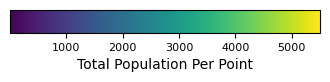

In [7]:
# -----------------------------
# 1. Define output folders
# -----------------------------

base_output_folder = output_folder   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_2020_total_population_interactive_map.html"
)

# -----------------------------
# 2. Build viridis colour scale
# -----------------------------

vmin = total_pop_gdf["total_population"].min()
vmax = total_pop_gdf["total_population"].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("viridis")

def to_hex(v):
    rgba = cmap(norm(v))
    return mcolors.to_hex(rgba)

total_pop_gdf["colour"] = total_pop_gdf["total_population"].apply(to_hex)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (total_pop_gdf["x"].max() + total_pop_gdf["x"].min()) / 2
y = (total_pop_gdf["y"].max() + total_pop_gdf["y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap(
    "Esri.WorldImagery",
    before_id=m.first_symbol_layer_id,
    visible=True
)

m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Plain)",
    attribution="Esri World Imagery",
    visible=False
)


# Data layers
m.add_gdf(
    gdf=total_pop_gdf,
    name="Total Population",
    layer_type="circle",
    paint={"circle-radius": 3, "circle-color": ["get", "colour"]},
    visible=True
)

m.add_gdf(
    swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

# -----------------------------
# 4. Generate static colour bar PNG & Add to map
# -----------------------------

colorbar_path = os.path.join(assets_folder, "total_pop_colorbar.png")

common.save_colorbar(out_fig=colorbar_path,
                     label="Total Population Per Point",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")

html = f'<img src="{colorbar_path}">'
m.add_html(html, position="bottom-right")

# -----------------------------
# 5. Add map title / sources
# -----------------------------

m.add_text(
    "Estimated Total Population in Sarawak in 2020",
    position="top-left",
    font_size=12
)

# -----------------------------
# 6. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Total Population",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery",
        "Esri.WorldImagery (Plain)"
    ],
    position="top-left"
)

# -----------------------------
# 7. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Total Population in Sarawak (2020)",
    overwrite=True
)

m

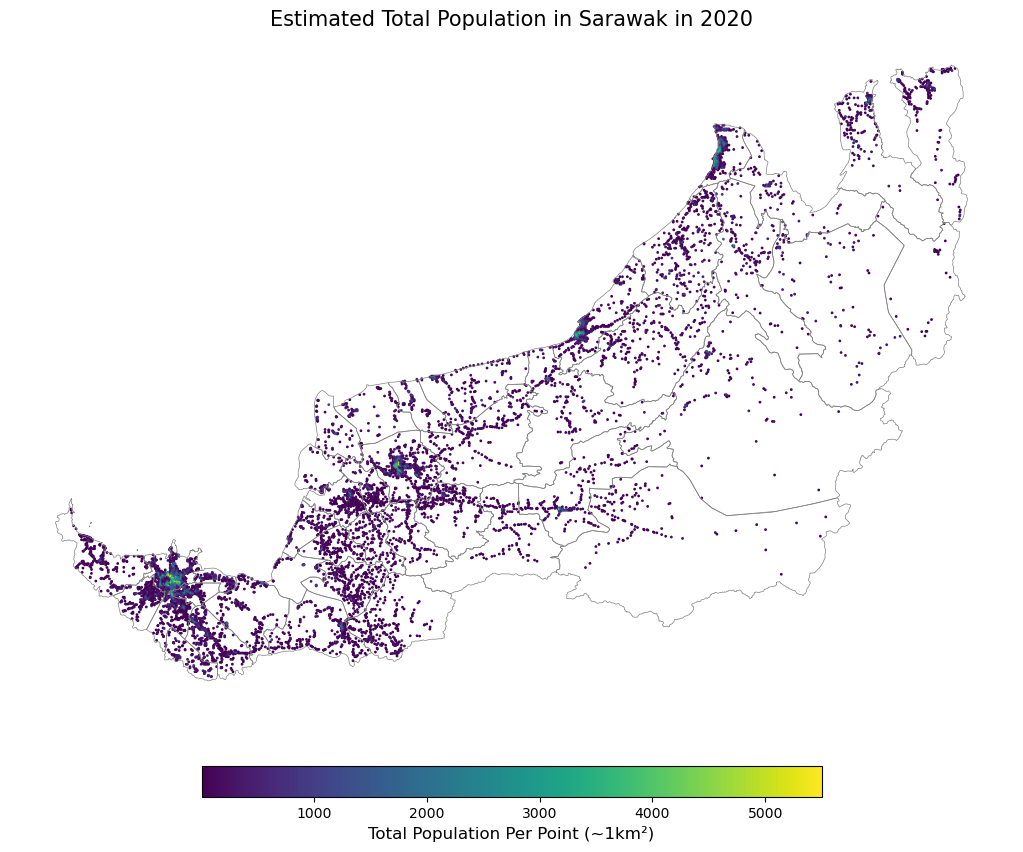

In [8]:
# Create static plot of the total population distribution
plt.figure(figsize=(16, 10))

# Extract x, y coordinates
x = total_pop_gdf.geometry.x
y = total_pop_gdf.geometry.y
values = total_pop_gdf["total_population"]

# Create scatter plot directly
scatter = plt.scatter(
    x, y,
    c=values,
    cmap="viridis",
    s=1
)

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), edgecolor='grey', linewidth=0.5)

# Add colourbar properly
cbar = plt.colorbar(scatter, orientation='horizontal',shrink=0.5, fraction=0.05, pad=0.07)
cbar.set_label('Total Population Per Point (~1km²)', fontsize=12)

plt.title(f"Estimated Total Population in Sarawak in 2020", fontsize=15)
plt.axis("off")
plt.show()


Plotting primary and secondary school students

In [9]:
# Combine total_pop_gdf, primary_pop_gdf, secondary_pop_gdf into a single gdf
combined_pop_gdf = total_pop_gdf.merge(
    primary_pop_gdf[["pop_id", "primary_school_students"]],
    on="pop_id"
).merge(
    secondary_pop_gdf[["pop_id", "secondary_school_students"]],
    on="pop_id"
)

combined_pop_gdf = combined_pop_gdf[["pop_id","total_population","primary_school_students","secondary_school_students","x","y","geometry"]]

Html(children=[<leafmap.maplibregl.Map object at 0x000001A882F2BA00>, Card(children=[Btn(children=[Icon(childr…

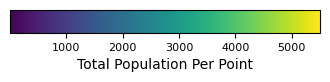

In [10]:
# -----------------------------
# 1. Define output folders
# -----------------------------

base_output_folder = output_folder   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_2020_student_population_interactive_map.html"
)

# -----------------------------
# 2. Build viridis colour scale
# -----------------------------

vmin = combined_pop_gdf["total_population"].min()
vmax = combined_pop_gdf["total_population"].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("viridis")

def to_hex(v):
    rgba = cmap(norm(v))
    return mcolors.to_hex(rgba)

combined_pop_gdf["colour"] = combined_pop_gdf["total_population"].apply(to_hex)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (combined_pop_gdf["x"].max() + combined_pop_gdf["x"].min()) / 2
y = (combined_pop_gdf["y"].max() + combined_pop_gdf["y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=True)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Plain)",
    attribution="Esri World Imagery",
    visible=False
)

# Data layers
m.add_gdf(
    gdf=combined_pop_gdf,
    name="Population Points",
    layer_type="circle",
    paint={"circle-radius": 3, "circle-color": ["get", "colour"]},
    visible=True
)

m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

# -----------------------------
# 4. Add school layers
# -----------------------------

# -- Secondary Schools ---
image_sec = "Interactive Maps/assets/icons/college_orange.png"

secondary_geojson = json.loads(secondary_school_gdf.to_json())
source_sec = {"type": "geojson", "data": secondary_geojson}

layer_sec = {
    "id": "Secondary Schools",
    "type": "symbol",
    "source": "point_sec",
    "layout": {
        "icon-image": "sec_school",
        "icon-size": 0.08}
}

m.add_image("sec_school", image_sec)
m.add_source("point_sec", source_sec)
m.add_layer(layer_sec)
m.add_popup("Secondary Schools")

# -- Secondary Schools ---
image_pri = "Interactive Maps/assets/icons/college_blue.png"

primary_geojson = json.loads(primary_school_gdf.to_json())
source_pri = {"type": "geojson", "data": primary_geojson}

layer_pri = {
    "id": "Primary Schools",
    "type": "symbol",
    "source": "point_pri",
    "layout": {
        "icon-image": "pri_school",
        "icon-size": 0.08}
}

m.add_image("pri_school", image_pri)
m.add_source("point_pri", source_pri)
m.add_layer(layer_pri)
m.add_popup("Primary Schools")

# -----------------------------
# 5. Generate static colour bar PNG & Add to map
# -----------------------------

colorbar_path = os.path.join(assets_folder, "total_pop_colorbar_incl_stu.png")

common.save_colorbar(out_fig=colorbar_path,
                     label="Total Population Per Point",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")

html = f'<img src="{colorbar_path}">'
m.add_html(html, position="bottom-right")

#----------------------------
# 6. Add map title / sources
# -----------------------------

m.add_text(
    "Estimated Total Population and Students in Sarawak in 2020",
    position="top-left",
    font_size=12
)

# -----------------------------
# 7. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Population Points",
        "Secondary Schools",
        "Primary Schools",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery",
        "Esri.WorldImagery (Plain)"
    ],
    position="top-left"
)

# -----------------------------
# 8. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Total Population and Students in Sarawak (2020)",
    overwrite=True
)

m

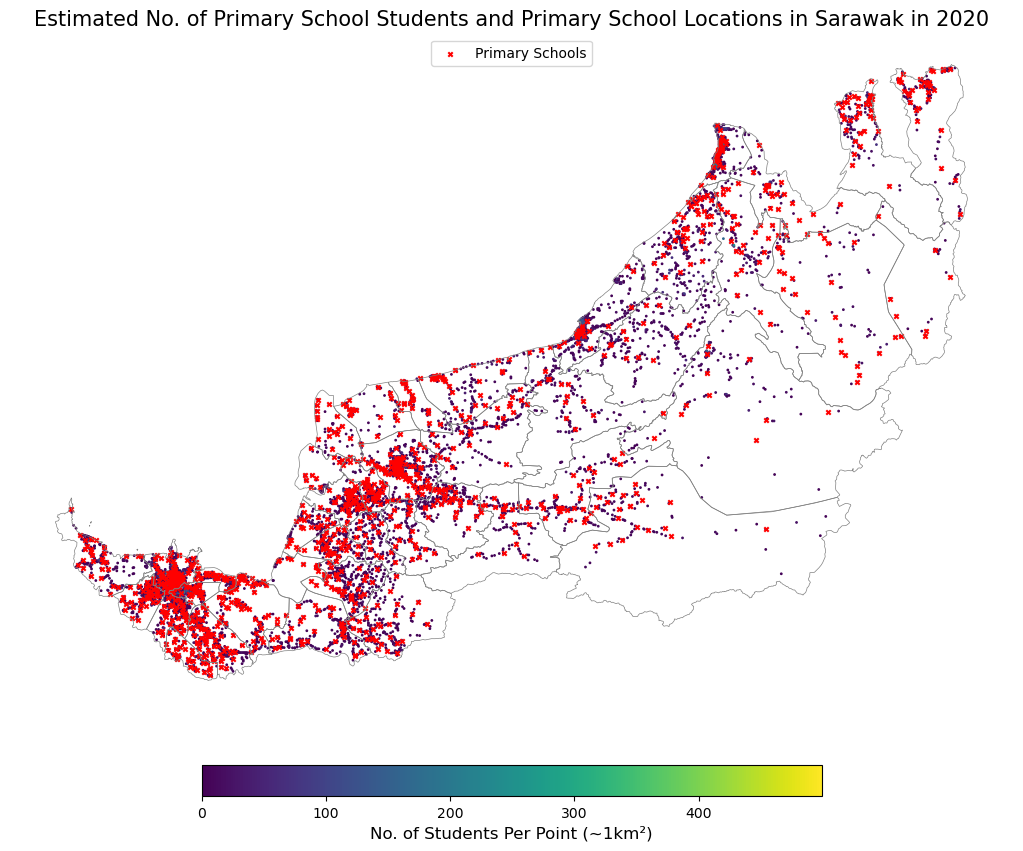

In [11]:
# Create static plot of the primary school distribution
plt.figure(figsize=(16, 10))

# Extract x, y coordinates
x = primary_pop_gdf.geometry.x
y = primary_pop_gdf.geometry.y
values = primary_pop_gdf["primary_school_students"]

# Create scatter plot directly
scatter = plt.scatter(
    x, y,
    c=values,
    cmap="viridis",
    s=1
)

# Add school locations
primary_school_gdf.geometry.plot(ax=plt.gca(), markersize=10, marker="x", color="red",label='Primary Schools')

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), edgecolor='grey', linewidth=0.5)

# Add colourbar properly
cbar = plt.colorbar(scatter, orientation='horizontal',shrink=0.5, fraction=0.05, pad=0.07)
cbar.set_label('No. of Students Per Point (~1km²)', fontsize=12)

# Add legend for schools
plt.legend(loc='upper center')

plt.title(f"Estimated No. of Primary School Students and Primary School Locations in Sarawak in 2020", fontsize=15)
plt.axis("off")
plt.show()


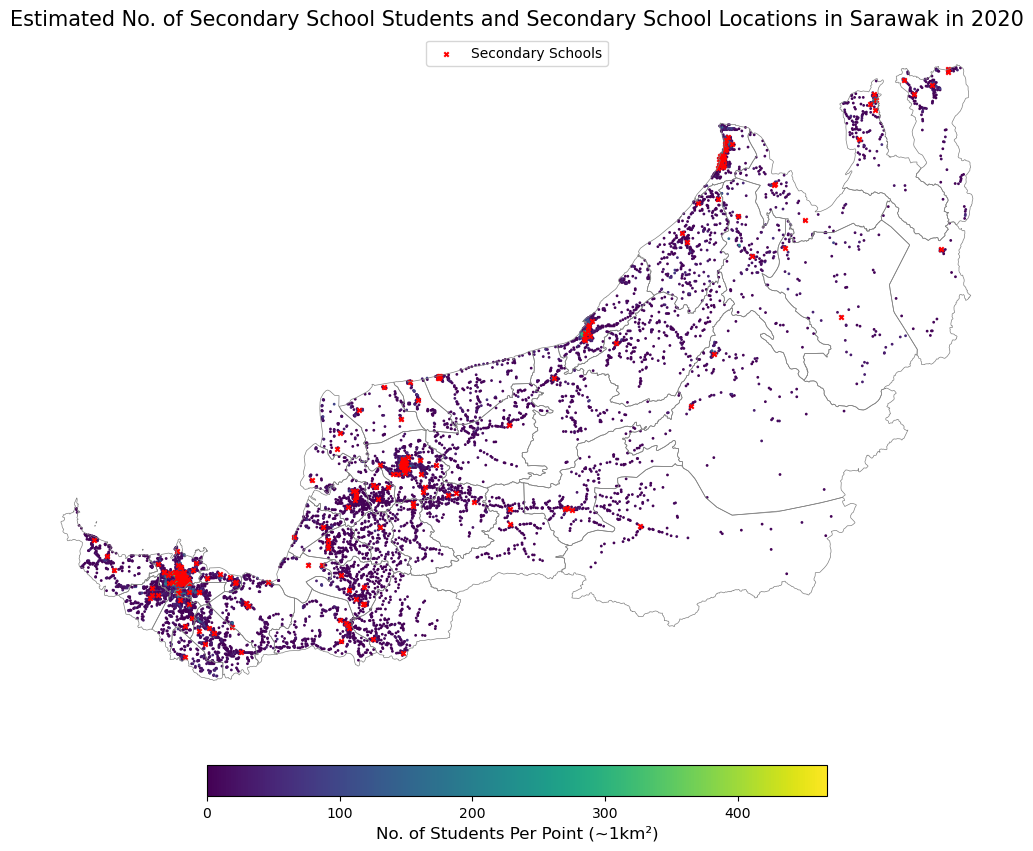

In [12]:
# Create static plot of the primary school distribution
plt.figure(figsize=(16, 10))

# Extract x, y coordinates
x = secondary_pop_gdf.geometry.x
y = secondary_pop_gdf.geometry.y
values = secondary_pop_gdf["secondary_school_students"]

# Create scatter plot directly
scatter = plt.scatter(
    x, y,
    c=values,
    cmap="viridis",
    s=1
)

# Add school locations
secondary_school_gdf.geometry.plot(ax=plt.gca(), markersize=10, marker="x", color="red",label='Secondary Schools')

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), edgecolor='grey', linewidth=0.5)

# Add colourbar properly
cbar = plt.colorbar(scatter, orientation='horizontal',shrink=0.5, fraction=0.05, pad=0.07)
cbar.set_label('No. of Students Per Point (~1km²)', fontsize=12)

# Add legend for schools
plt.legend(loc='upper center')

plt.title(f"Estimated No. of Secondary School Students and Secondary School Locations in Sarawak in 2020", fontsize=15)
plt.axis("off")
plt.show()
